In [12]:
import pandas as pd

from sklearn.ensemble import GradientBoostingRegressor

from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt

import numpy as np

In [13]:
X_train = pd.read_csv("../data/X_train.csv")
X_test = pd.read_csv("../data/X_test.csv")

y_train = pd.read_csv("../data/y_train.csv").squeeze()
y_test = pd.read_csv("../data/y_test.csv").squeeze()

In [14]:
baseline = GradientBoostingRegressor(
    random_state=42
)

baseline.fit(X_train, y_train)

baseline_predictions = baseline.predict(X_test)

In [15]:
param_grid = {

    "n_estimators":[100,200,300],

    "learning_rate":[0.01,0.05,0.1],

    "max_depth":[2,3,4],

    "subsample":[0.8,1.0]

}

In [16]:
grid = GridSearchCV(

    estimator=GradientBoostingRegressor(random_state=42),

    param_grid=param_grid,

    cv=5,

    scoring="r2",

    n_jobs=-1

)

grid.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.05, ...], 'max_depth': [2, 3, ...], 'n_estimators': [100, 200, ...], 'subsample': [0.8, 1.0]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose v

In [17]:
print(grid.best_params_)

print(grid.best_score_)

{'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 300, 'subsample': 1.0}
0.9057289337714713


In [18]:
best_model = grid.best_estimator_

In [19]:
predictions = best_model.predict(X_test)

In [20]:
mae = mean_absolute_error(y_test,predictions)

rmse = np.sqrt(
    mean_squared_error(y_test,predictions)
)

r2 = r2_score(
    y_test,
    predictions
)

print(mae)
print(rmse)
print(r2)

10.034490546070321
27.692860299731436
0.9432402457660961


In [21]:
comparison = pd.DataFrame({

    "Model":[
        "Baseline GB",
        "Tuned GB"
    ],

    "MAE":[
        10.19,
        mae
    ],

    "RMSE":[
        34.97,
        rmse
    ],

    "R2":[
        0.901,
        r2
    ]

})

comparison

,Model,MAE,RMSE,R2
0,Baseline GB,10.190000,34.97000,0.90100
1,Tuned GB,10.034491,27.69286,0.94324


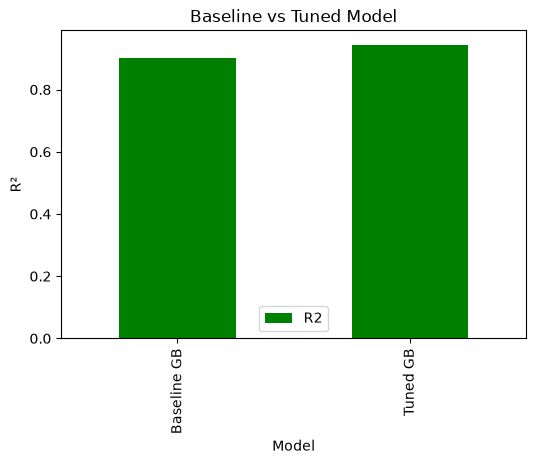

In [22]:
comparison.set_index("Model")[["R2"]].plot(
    kind="bar",
    color="green",
    figsize=(6,4)
)

plt.title("Baseline vs Tuned Model")
plt.ylabel("R²")
plt.show()

In [23]:
import joblib

joblib.dump(
    best_model,
    "../models/final_gradient_boosting.pkl"
)

['../models/final_gradient_boosting.pkl']